In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import requests
import matplotlib.pyplot as plt
import koreanize_matplotlib
import yfinance as yf
from datetime import date

# 행(row) 다 보기
pd.set_option('display.max_rows', None)

# 열(column) 다 보기
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns', None)
from PublicDataReader import Ecos

service_key = "2G5XUDEN750MGRZM37GF"
api = Ecos(service_key)
df = api.get_statistic_table_list()
df.head()

,상위통계표코드,통계표코드,통계명,시점,검색가능여부,출처
0,*,0000000001,1. 통화/금융,None,N,None
1,0000000001,0000000620,1.1. 통화/유동성(신지표),None,N,None
2,0000000620,0000000621,1.1.1. 본원통화,None,N,None
3,0000000621,0000000622,1.1.1.1. 본원통화 구성내역,None,N,None
4,0000000622,102Y004,"1.1.1.1.1. 본원통화 구성내역(평잔, 계절조정계열)",M,Y,None


### M2(광의통화)

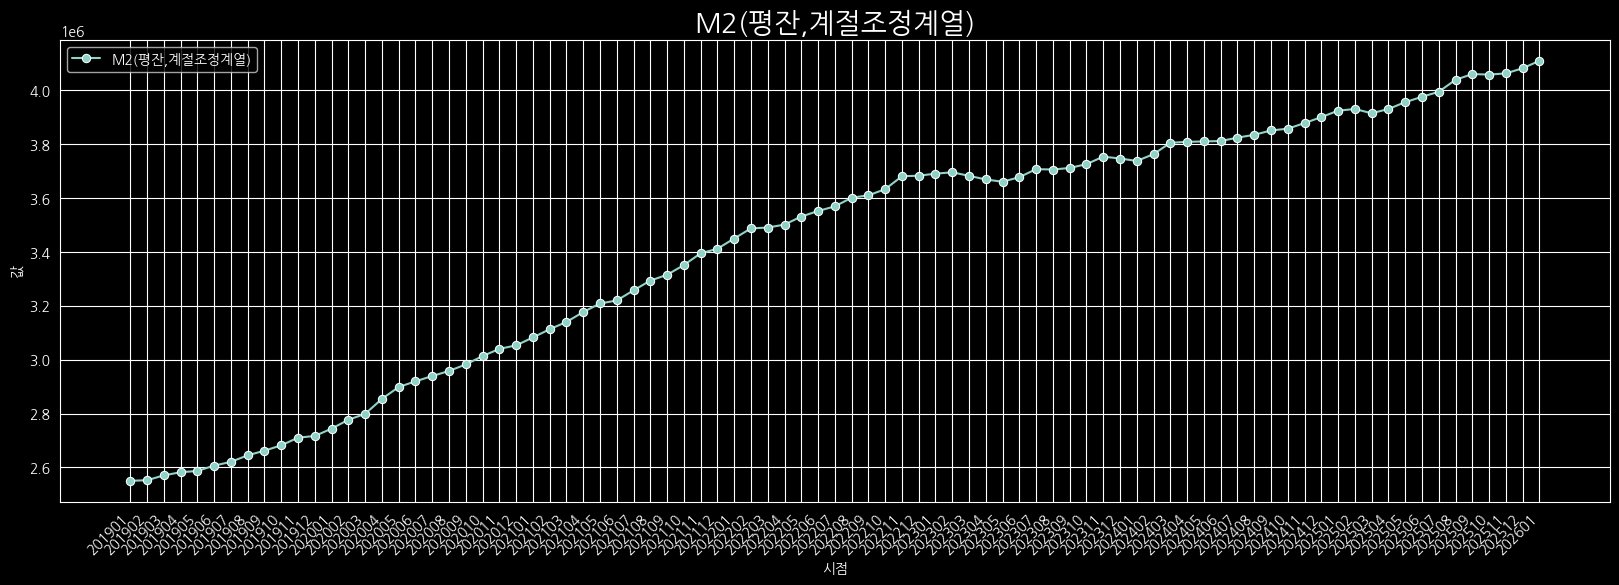

In [3]:
df_m2 = api.get_statistic_search(통계표코드="161Y005", 주기="M", 검색시작일자="201901", 검색종료일자="202612")
df_m2['값'] = df_m2['값'].astype(float)

plt.figure(figsize=(20,6))  # 그림 넓게
sns.lineplot(x="시점", y="값", data=df_m2[df_m2['통계항목명1'] == 'M2(평잔,계절조정계열)'], hue='통계항목명1', marker='o')

# x축 레이블 회전
plt.xticks(rotation=45, ha='right')
plt.title("M2(평잔,계절조정계열)", fontsize=20)
plt.legend()
plt.show()

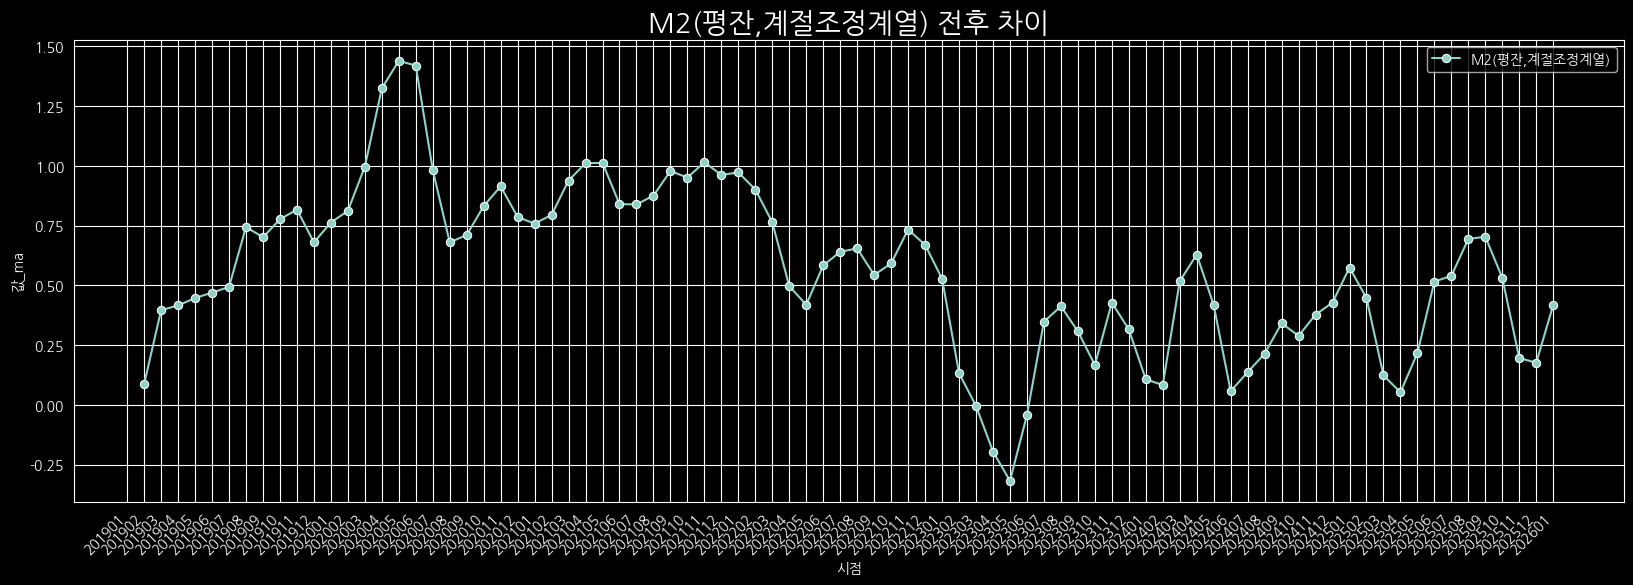

In [4]:
df_tmp = df_m2[df_m2['통계항목명1'] == 'M2(평잔,계절조정계열)'].copy()
df_tmp['값_prev'] = df_tmp['값'].shift(1)
df_tmp['값_ratio'] = ((df_tmp['값'] / df_tmp['값_prev']) - 1) * 100
df_tmp['값_ma'] = df_tmp['값_ratio'].rolling(window=3, min_periods=1).mean()

plt.figure(figsize=(20,6))  # 그림 넓게
sns.lineplot(x="시점", y="값_ma", data=df_tmp, hue='통계항목명1', marker='o')

# x축 레이블 회전
plt.xticks(rotation=45, ha='right')
plt.title("M2(평잔,계절조정계열) 전후 차이", fontsize=20)
plt.legend()
plt.show()

In [5]:
df_m2_tot = df_m2[df_m2['통계항목명1'] == 'M2(평잔,계절조정계열)'][['시점','값']].rename(columns={'값':'tot'}).copy()
df_m2_else = df_m2[df_m2['통계항목명1'] != 'M2(평잔,계절조정계열)'].copy()

df_m2_comp = df_m2_else.merge(df_m2_tot, on='시점')
df_m2_comp['ratio'] = np.round((df_m2_comp['값'] / df_m2_comp['tot']), 2) * 100
df_m2_comp.head()

,통계표코드,통계명,통계항목코드1,통계항목명1,통계항목코드2,통계항목명2,통계항목코드3,통계항목명3,통계항목코드4,통계항목명4,단위,WGT,시점,값,tot,ratio
0,161Y005,"1.1.3.1.1. M2 상품별 구성내역(평잔, 계절조정계열)",BBHS01,현금통화,None,None,None,None,None,None,십억원,None,201901,103481.4,2550186.4,4.0
1,161Y005,"1.1.3.1.1. M2 상품별 구성내역(평잔, 계절조정계열)",BBHS02,요구불예금,None,None,None,None,None,None,십억원,None,201901,232453.4,2550186.4,9.0
2,161Y005,"1.1.3.1.1. M2 상품별 구성내역(평잔, 계절조정계열)",BBHS03,수시입출식저축성예금,None,None,None,None,None,None,십억원,None,201901,515350.1,2550186.4,20.0
3,161Y005,"1.1.3.1.1. M2 상품별 구성내역(평잔, 계절조정계열)",BBHS04,MMF 지분,None,None,None,None,None,None,십억원,None,201901,87130.6,2550186.4,3.0
4,161Y005,"1.1.3.1.1. M2 상품별 구성내역(평잔, 계절조정계열)",BBHS05,만기2년미만정기예적금,None,None,None,None,None,None,십억원,None,201901,1107508.8,2550186.4,43.0


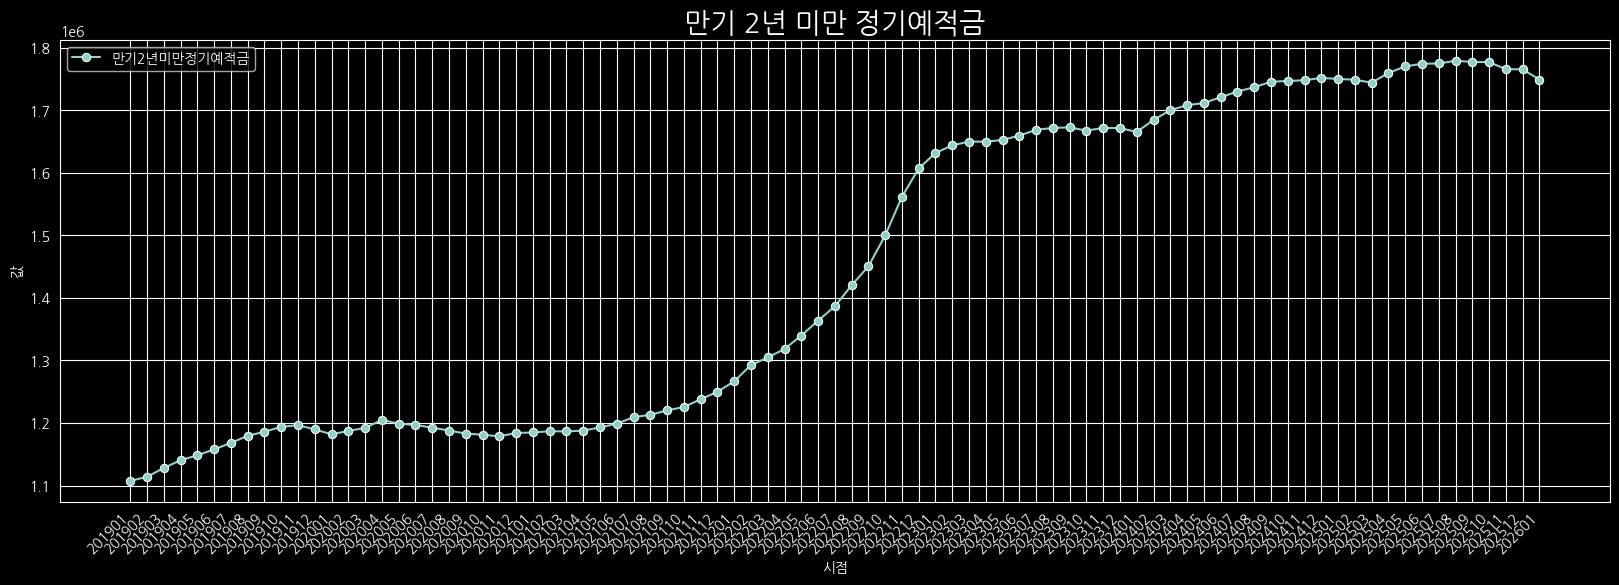

In [6]:
plt.figure(figsize=(20,6))  # 그림 넓게
sns.lineplot(x="시점", y="값",
             data=df_m2_comp[df_m2_comp['통계항목명1'].isin([ '만기2년미만정기예적금'])],
             hue='통계항목명1', marker='o')

# x축 레이블 회전
plt.xticks(rotation=45, ha='right')
plt.title("만기 2년 미만 정기예적금", fontsize=20)
plt.legend()
plt.show()

### 유입자금 방향

In [7]:
df_flow = api.get_statistic_search(통계표코드="161Y015", 주기="M", 검색시작일자="201901", 검색종료일자="202612")
df_flow['값'] = df_flow['값'].astype(float)

In [8]:
list_input_var = [ "요구불예금", "수시입출식저축성예금", "CMA", "MMF 지분", "환매조건부채권매도"]
list_output_var = ['예수금 (M2 제외)', '채무증권(M2 제외)', '자본계정']

df_flow_input = (
    pd.pivot(data=df_flow[df_flow['통계항목명1'].isin(list_input_var)], index='시점', columns='통계항목명1', values='값').fillna(0).reset_index()
)

df_flow_output = (
    pd.pivot(data=df_flow[df_flow['통계항목명1'].isin(list_output_var)], index='시점', columns='통계항목명1', values='값').fillna(0).reset_index()
)

df_flow_merged = df_flow_input.merge(df_flow_output, on ='시점')
df_flow_merged['시점'] = pd.to_datetime(df_flow_merged['시점'], format='%Y%m')

In [9]:
df_flow_merged.tail()

통계항목명1,시점,CMA,MMF 지분,수시입출식저축성예금,요구불예금,환매조건부채권매도,예수금 (M2 제외),자본계정,채무증권(M2 제외)
80,2025-09-01,90457.9,154587.4,754230.5,404932.9,7794.2,354033.9,424953.3,128776.2
81,2025-10-01,91936.6,167024.9,730927.4,391973.3,7960.4,358345.0,426593.4,129423.6
82,2025-11-01,92579.7,166182.8,743904.0,394979.8,7377.5,359223.4,429435.2,125718.9
83,2025-12-01,99201.6,157819.5,780900.6,404382.3,5330.2,355295.3,433635.1,121966.8
84,2026-01-01,101172.2,181129.7,747258.6,389469.5,7182.4,356079.1,440934.7,125515.8


#### 주식시장으로 돈이 몰리나?
- 요구불예금 : 언제든지 요구하면 바로 인출 가능한 예금 (보통예금, 당좌예금, 기업결제용 계좌, 체크카드 연결 계좌, 급여통장)
- CMA : 증권사가 운영하는 이자 붙는 현금 계좌
- MMF : 초단기 금융상품에 투자하는 현금 대용 펀드 (요구불예금 - CMA - 주식/채권), 보통 국공채 단기물이나 RP, 통안채에 투자해

- **요구불예금가 줄어들면서 CMA나 MMF로 증가하는 것으로 보아 주식시장으로 갈 준비를 하고 있음**

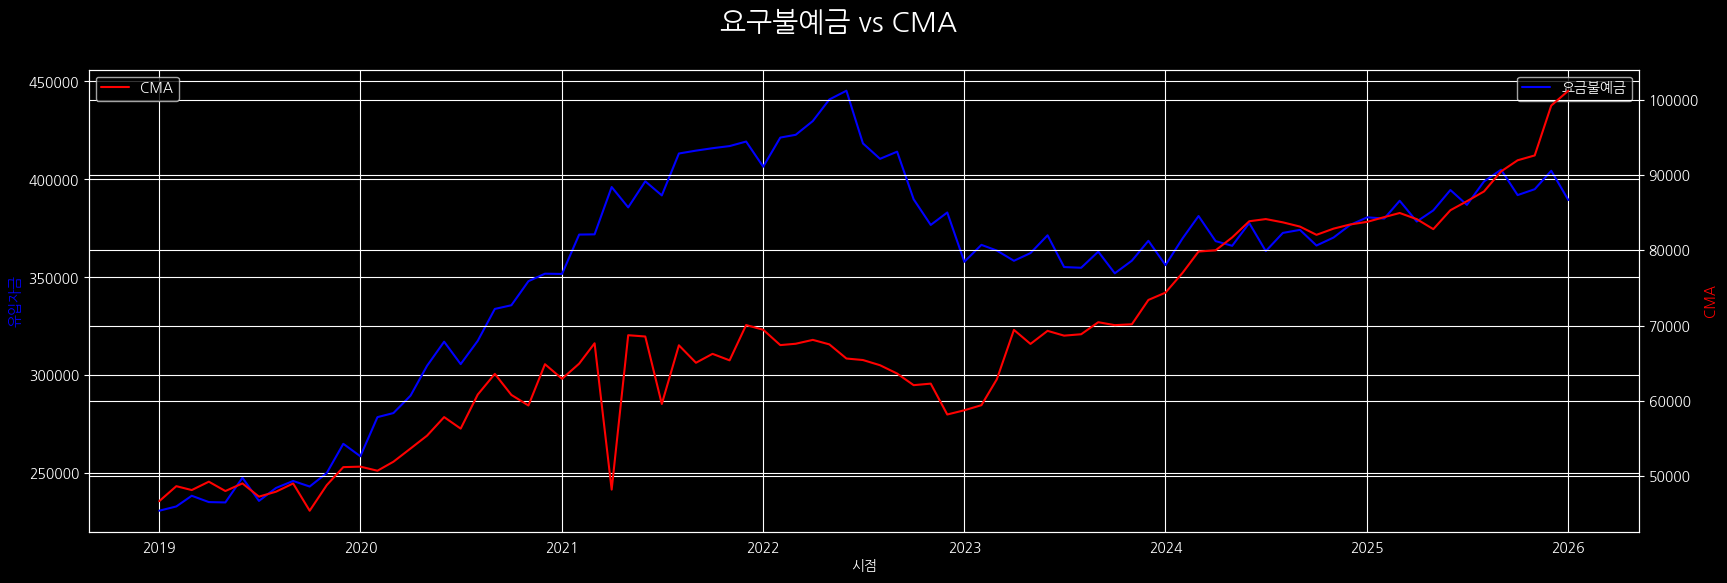

In [10]:
fig, ax1 = plt.subplots(figsize=(20,6))
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["요구불예금"], ax=ax1, label="요금불예금", color='blue')
ax1.set_ylabel('유입자금', color='blue')

ax2 = ax1.twinx()
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["CMA"], ax=ax2, label="CMA", color='red')
ax2.set_ylabel('CMA', color='red')

fig.suptitle('요구불예금 vs CMA', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

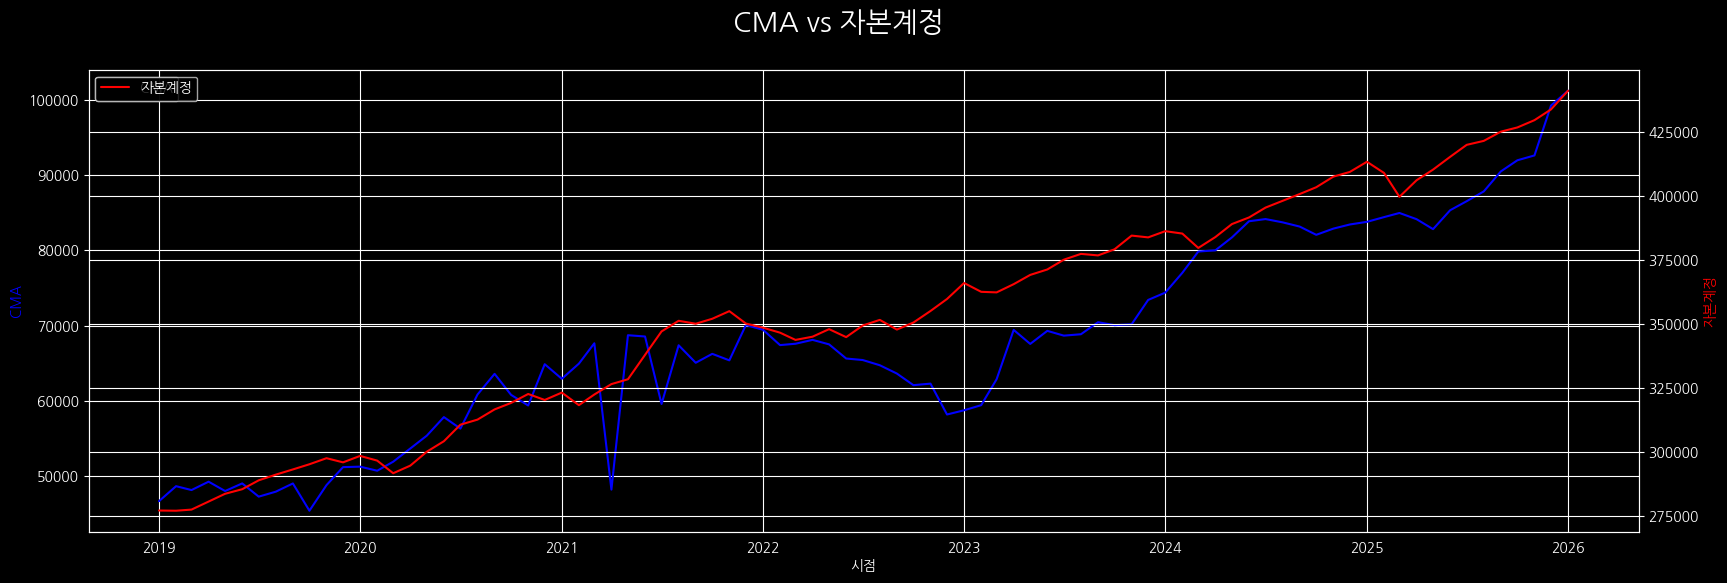

In [11]:
fig, ax1 = plt.subplots(figsize=(20,6))
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["CMA"], ax=ax1, label="CMA", color='blue')
ax1.set_ylabel('CMA', color='blue')

ax2 = ax1.twinx()
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["자본계정"], ax=ax2, label="자본계정", color='red')
ax2.set_ylabel('자본계정', color='red')

fig.suptitle('CMA vs 자본계정', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

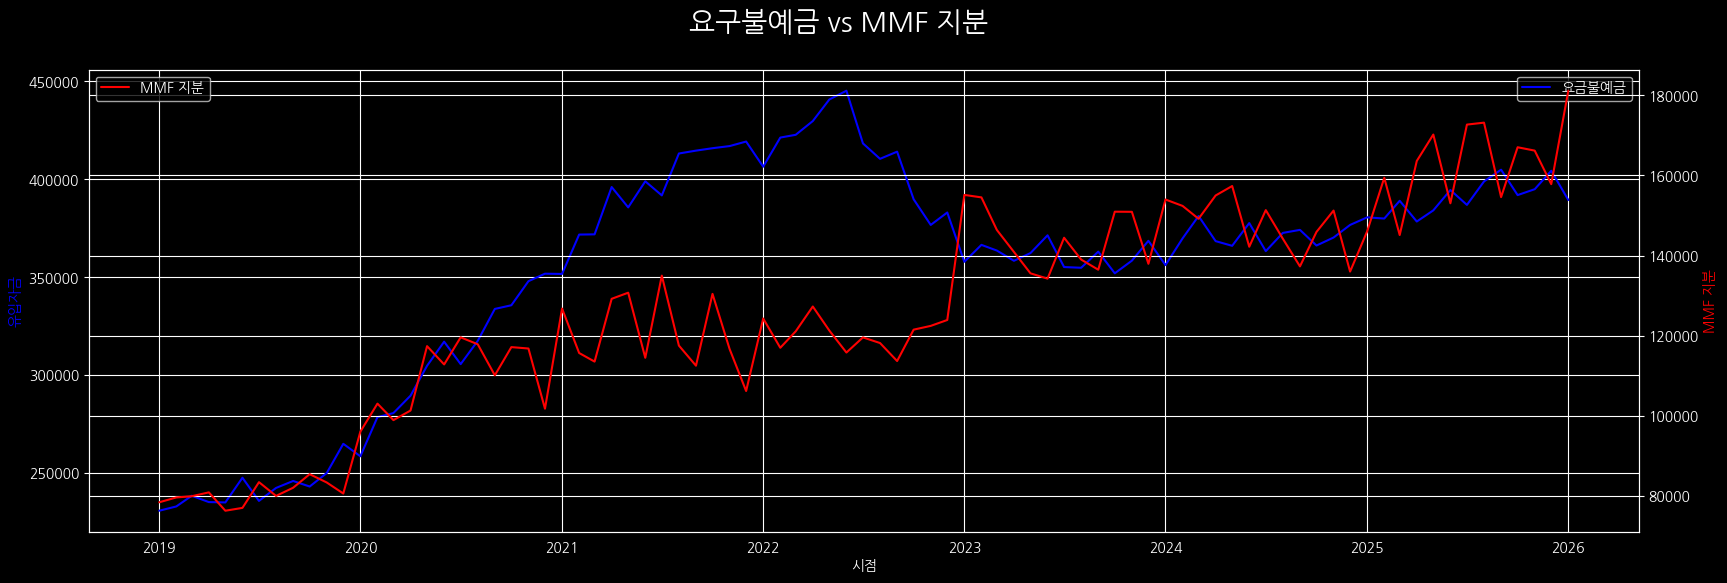

In [12]:
fig, ax1 = plt.subplots(figsize=(20,6))
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["요구불예금"], ax=ax1, label="요금불예금", color='blue')
ax1.set_ylabel('유입자금', color='blue')

ax2 = ax1.twinx()
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["MMF 지분"], ax=ax2, label="MMF 지분", color='red')
ax2.set_ylabel('MMF 지분', color='red')

fig.suptitle('요구불예금 vs MMF 지분', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

#### 예수금
- 주식시장과 반대로 가는 성격
- 은행 안에서 묶인 돈
- 장기,조건부,유동성 낮금은 예금


#### 채무증권
- 채권시장
- 금융채, 회사채, 장기채

#### 자본계정
- 주식
- 펀드
- 기업자충본 확충

- 자본계정과 예수금이 같이 움직인다는 것은 총 유동성 확장 국면 즉, 돈 자체가 늘어난다는 의미
    + 임금, 이자, 배당 증가
    + 정부 지출
    + 기업 이익 확대


- 자본계정과 채무증권이 음의 관계인 이유
    + 채무증권은 확정수익이자 금리 방향 베팅, 위험 해피 성향이라면 자본계정은 변동 수익, 성장 기대, 위험 감수
    + 그래서 대체 관계가 됨

- 금리 고점 인식이 높으면, 채권 선호가 높고 자본계정은 떨어짐
- 성장 기대되면 자본계정이 높고 채무증권이 낮음

- 국면별
    + **예수금 높고, 자본계정 높으면 초기 확장**
    + **예수금 낮고, 자본계정 높으면 사람들이 손해 날 가능성을 감수하고 더 높은 수익을 기대하는 자산을 선택하는 국면**
    + **예수금 높고, 자본계정 낮으면 위험 회피**

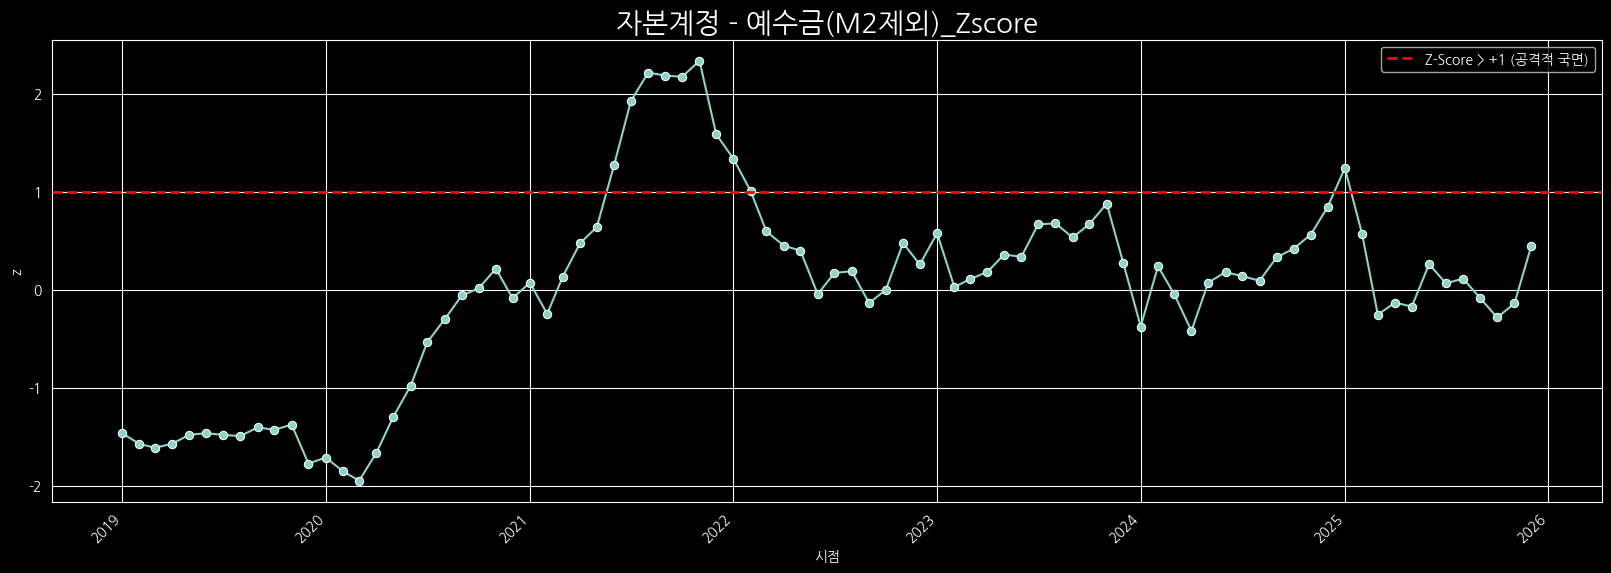

In [13]:
df_flow_merged['자본계정 - 예수금(M2제외)'] = df_flow_merged['자본계정'] - df_flow_merged["예수금 (M2 제외)"]
df_flow_merged['자본계정 - 예수금(M2제외)_diff'] = df_flow_merged['자본계정 - 예수금(M2제외)'].diff()
df_flow_merged['자본계정 - 예수금(M2제외)_pct'] = df_flow_merged['자본계정 - 예수금(M2제외)'].pct_change()

mean = df_flow_merged['자본계정 - 예수금(M2제외)'].mean()
std = df_flow_merged['자본계정 - 예수금(M2제외)'].std()
df_flow_merged['z'] = (df_flow_merged['자본계정 - 예수금(M2제외)'] - mean) / std

plt.figure(figsize=(20,6))  # 그림 넓게
sns.lineplot(x="시점", y="z",
             data=df_flow_merged,
             marker='o')


plt.axhline(
    y=1 ,          # 원하는 y좌표
    color='red',
    linestyle='--',
    linewidth=2,
    label='Z-Score > +1 (공격적 국면)'
)

# x축 레이블 회전
plt.xticks(rotation=45, ha='right')
plt.title("자본계정 - 예수금(M2제외)_Zscore", fontsize=20)
plt.legend()
plt.show()

In [14]:
# fig, ax1 = plt.subplots(figsize=(20,6))
# sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["자본계정"], ax=ax1, label="자본계정", color='blue')
# ax1.set_ylabel('자본계정', color='blue')
#
# ax2 = ax1.twinx()
# sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["예수금 (M2 제외)"], ax=ax2, label="예수금", color='red')
# ax2.set_ylabel('예수금', color='red')
#
# fig.suptitle('자본계정 vs 예수금', fontsize=20)
# plt.xticks(rotation=45, ha='right')
# plt.legend()
# plt.show()

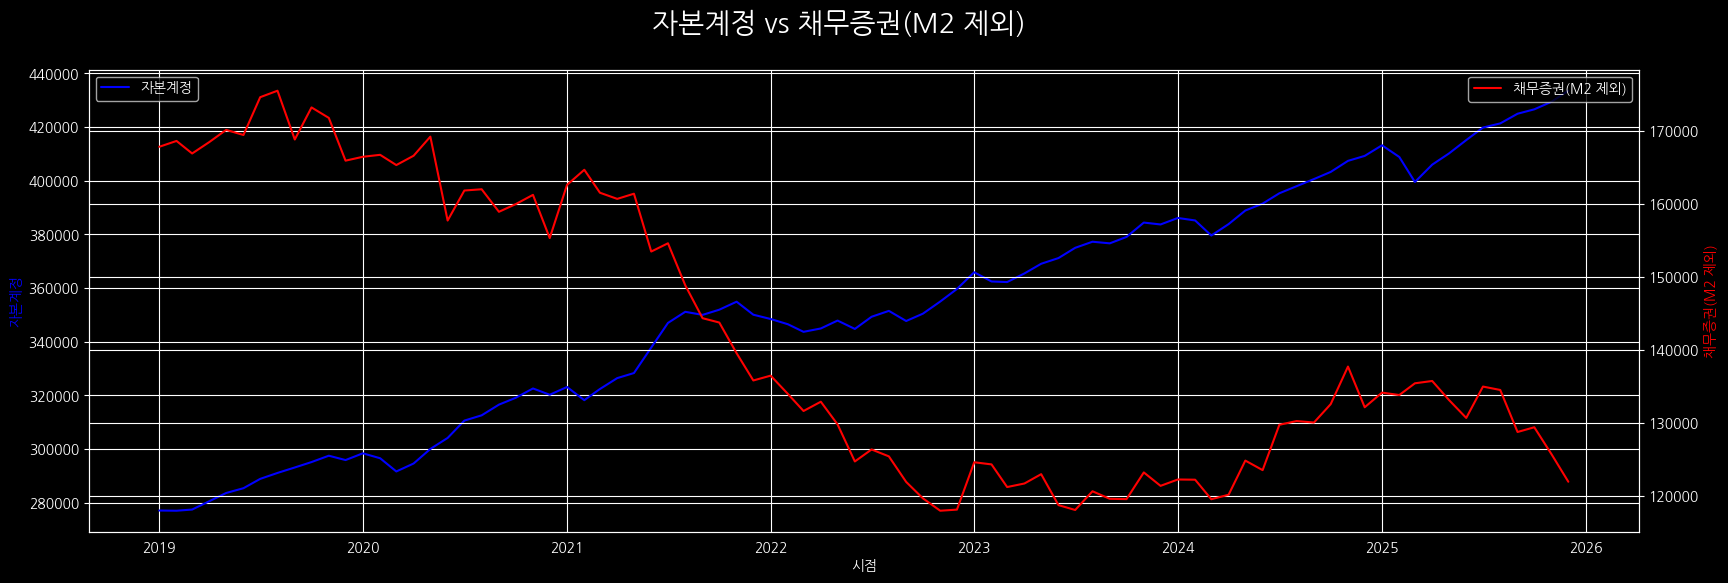

In [15]:
fig, ax1 = plt.subplots(figsize=(20,6))
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["자본계정"], ax=ax1, label="자본계정", color='blue')
ax1.set_ylabel('자본계정', color='blue')

ax2 = ax1.twinx()
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["채무증권(M2 제외)"], ax=ax2, label="채무증권(M2 제외)", color='red')
ax2.set_ylabel('채무증권(M2 제외)', color='red')

fig.suptitle('자본계정 vs 채무증권(M2 제외)', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

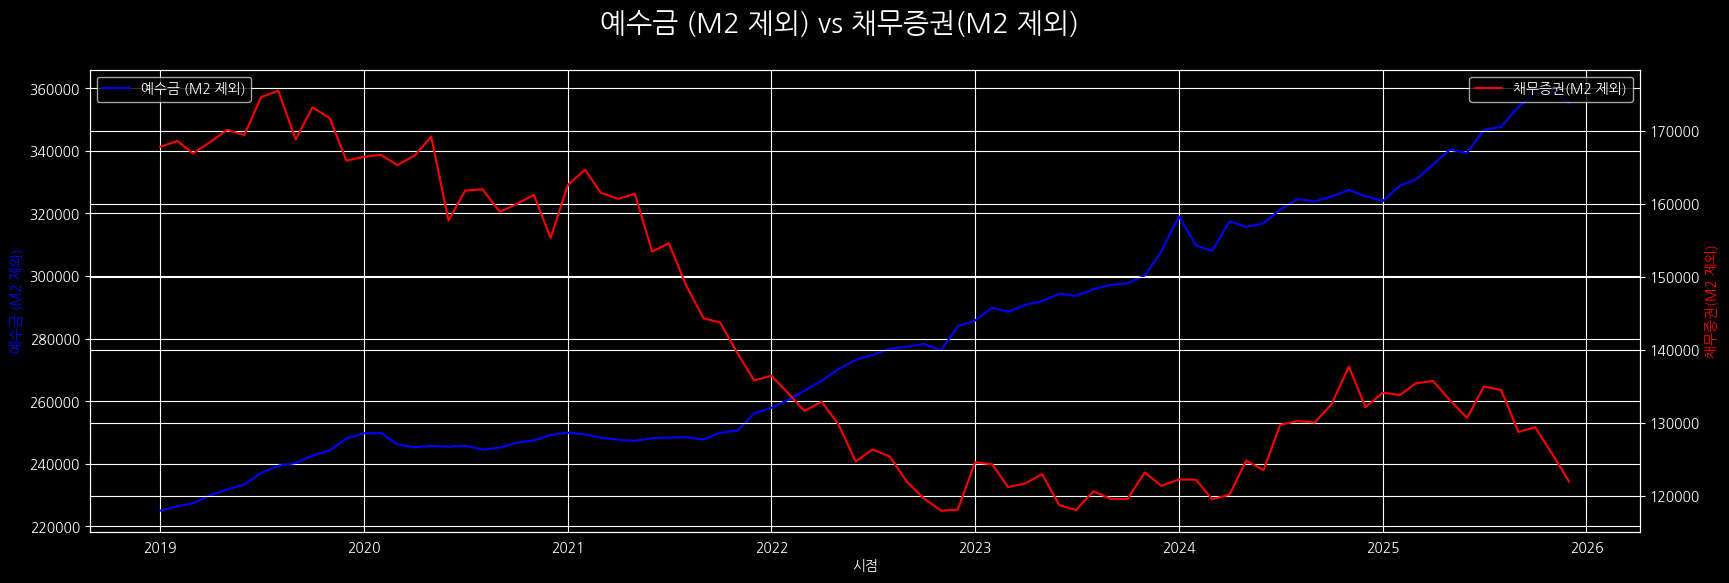

In [16]:
fig, ax1 = plt.subplots(figsize=(20,6))
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["예수금 (M2 제외)"], ax=ax1, label="예수금 (M2 제외)", color='blue')
ax1.set_ylabel('예수금 (M2 제외)', color='blue')

ax2 = ax1.twinx()
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["채무증권(M2 제외)"], ax=ax2, label="채무증권(M2 제외)", color='red')
ax2.set_ylabel('채무증권(M2 제외)', color='red')

fig.suptitle('예수금 (M2 제외) vs 채무증권(M2 제외)', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

#### 주식 시장에서 나와야 하는 국면(시장 과열 탐지)
- CMA 거의 비어 있음
- MMF 급감
- 빚(신용) 급증
- 채권 수감요 급감

#### 신용융자 잔고
- 투자자가 주식을 매수하기 위해 증권사에서 현금을 빌리는 것
- 담보 : 주식
- 목적 : 매수 레버리지
- 21년도에 23,088,636 백만

In [17]:
# crdTrFingWhl : 신용거래융자 - 전체
# crdTrFingScrs : 신용거래융자 - 유가증권
# crdTrFingKosdaq : 신용거래융자-코스닥
# crdTrLndrWhl : 신용거래대주 - 전체
# crdTrLndrScrs : 신용거래대주 - 유가증권
# crdTrLndrKosdaq : 신용거래대주 - 코스닥
# sbscCapLn : 청약자금 대출
# dpsgScrtMogFing : 예탹증권담보융자

In [18]:
url = "https://apis.data.go.kr/1160100/service/GetKofiaStatisticsInfoService/getGrantingOfCreditBalanceInfo"

dt = date.today().strftime("%Y-%m-%d")
list_date = pd.date_range("2023-01-01", dt, freq="B")

rows = []
for d in list_date:
    params = {
        "serviceKey": "D7/vw77XS3WkcDyqYpX+fxPV30EvQ6+ndwfybf7pOqwiDSA1o1xGvFrhWsbzHcF/MIPdZnOhNdfd1jAlyg+KVQ==",
        "pageNo": 1,
        "numOfRows": 100,
        "resultType": "json",
        "basDt": d.strftime("%Y%m%d")
    }
    res = requests.get(url, params=params)
    body = res.json().get("response", {}).get("body", {})
    items = body.get("items", {}).get("item", [])

    if items:
        rows.extend(items)


df_crd = pd.DataFrame(rows)
df_crd['crdTrFingWhl'] = df_crd['crdTrFingWhl'].astype(float)
df_crd.head()

KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(20,6))  # 그림 넓게
sns.lineplot(x="basDt", y="crdTrFingWhl",
             data=df_crd[df_crd.basDt > '20251001'], marker='o')

plt.axhline(
    y=22308863600000 ,          # 원하는 y좌표
    color='red',
    linestyle='--',
    linewidth=2,
    label='21년도 기준선'
)

# plt.xticks(
#     ticks=df_crd['basDt'][::60],   # 약 3개월(영업일 기준)
#     rotation=45,
#     ha='right'
# )
# x축 레이블 회전
plt.xticks(rotation=45, ha='right')
plt.title('신용거래융자 잔고 (일별)', fontsize=20)
plt.legend()
plt.show()

#### VIX 지수( 변동성 지수, 시장 불안 / 과열 동반 여부)
- VIX 지수가 15 미만이면 안도, 15~25이면 정상, 그 이상이면 급등 레버리지 청산 / 공포

In [13]:
vix = yf.download("^VIX", start="2020-01-01")
nasdaq = yf.download("^IXIC", start="2020-01-01")
df_vix_nasdaq = vix.join(nasdaq)
df_vix_nasdaq.columns = [ f"{col[0]}_{col[1]}" for col in df_vix_nasdaq.columns]
df_vix_nasdaq.tail()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,Close_^VIX,High_^VIX,Low_^VIX,Open_^VIX,Volume_^VIX,Close_^IXIC,High_^IXIC,Low_^IXIC,Open_^IXIC,Volume_^IXIC
Date,,,,,,,,,,
2026-03-23,26.150000,31.040001,20.280001,30.040001,0,21946.759766,22189.339844,21865.800781,21995.779297,8895880000
2026-03-24,26.950001,27.940001,25.639999,25.910000,0,21761.890625,21916.160156,21712.039062,21807.599609,8488380000
2026-03-25,25.330000,26.670000,24.820000,25.790001,0,21929.820312,22093.179688,21865.460938,22006.429688,8056920000
2026-03-26,27.440001,28.490000,26.120001,26.490000,0,21408.080078,21823.580078,21395.769531,21693.179688,7726590000
2026-03-27,31.049999,31.650000,27.540001,27.540001,0,20948.359375,21293.500000,20909.929688,21287.189453,8713310000


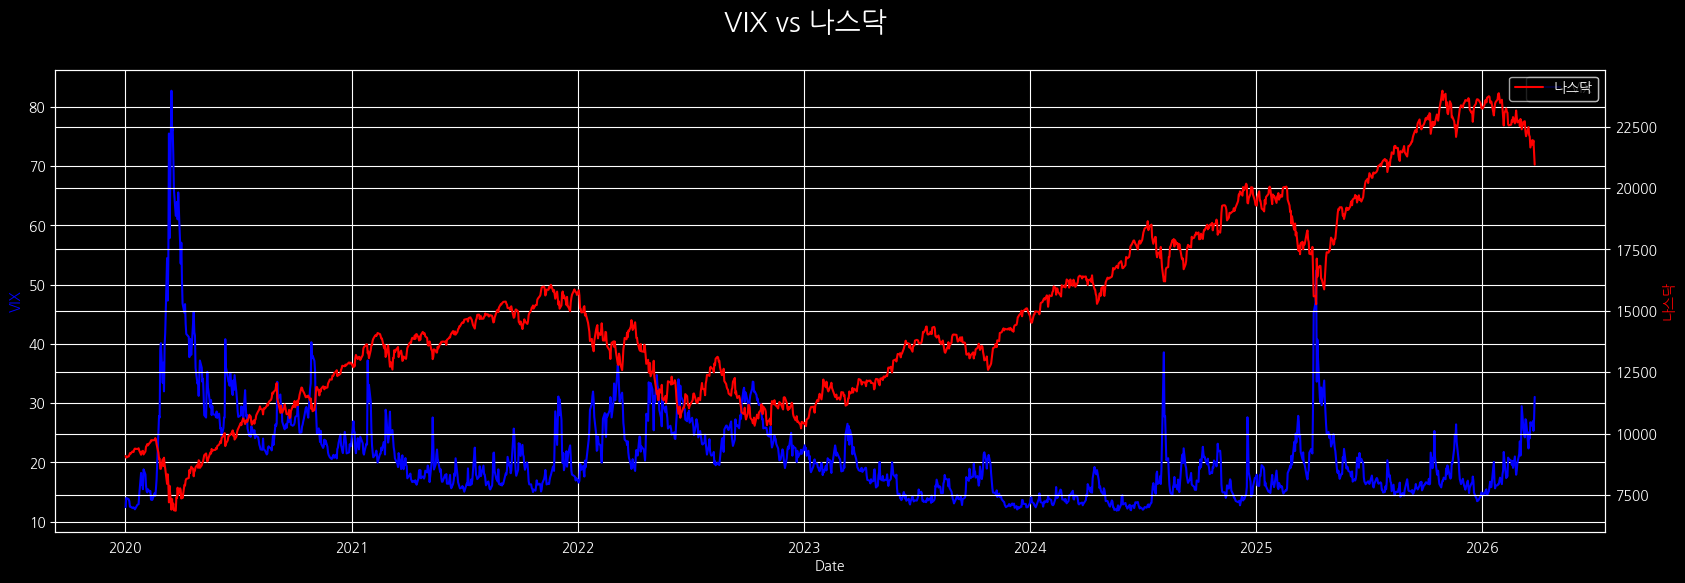

In [14]:
fig, ax1 = plt.subplots(figsize=(20,6))
sns.lineplot(x=df_vix_nasdaq.index, y=df_vix_nasdaq["Close_^VIX"], ax=ax1, label="VIX", color='blue')
ax1.set_ylabel('VIX', color='blue')

ax2 = ax1.twinx()
sns.lineplot(x=df_vix_nasdaq.index, y=df_vix_nasdaq["Close_^IXIC"], ax=ax2, label="나스닥", color='red')
ax2.set_ylabel('나스닥', color='red')

fig.suptitle('VIX vs 나스닥', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

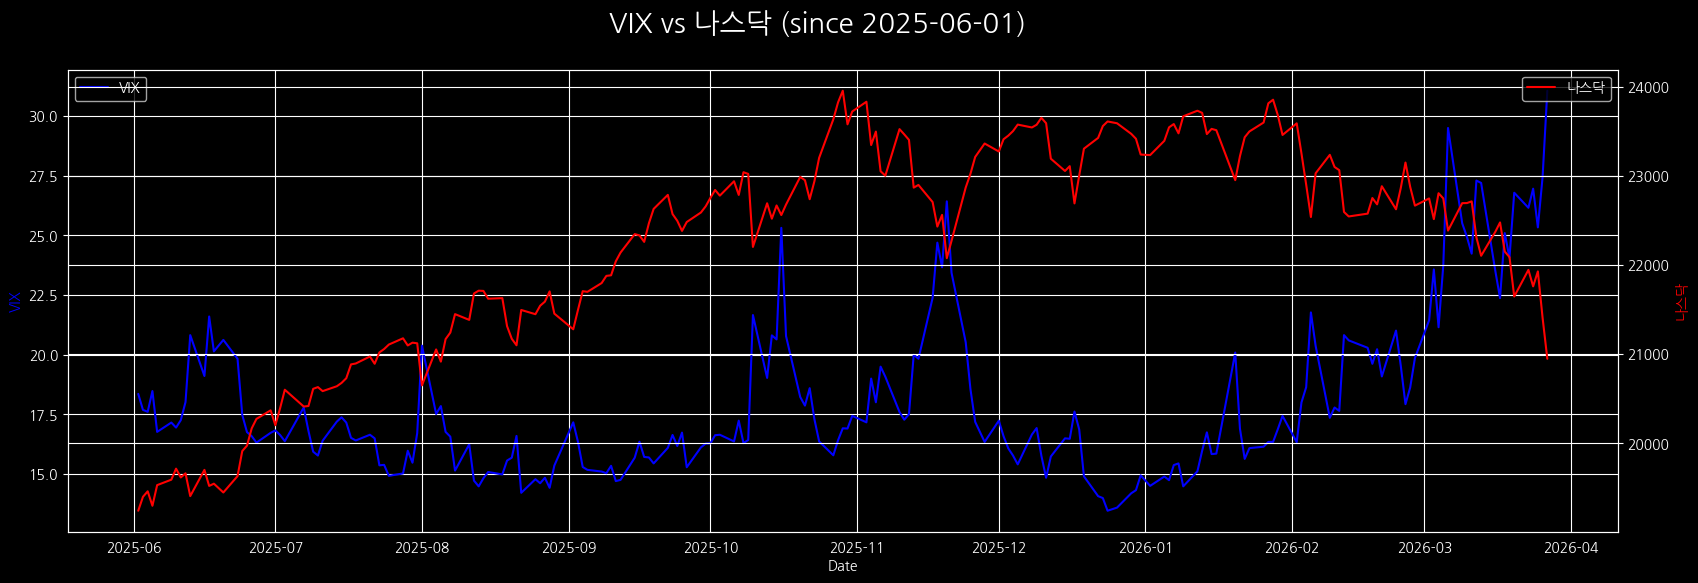

In [15]:
df_vix_nasdaq = df_vix_nasdaq[df_vix_nasdaq.index > '2025-06-01']
fig, ax1 = plt.subplots(figsize=(20,6))
sns.lineplot(x=df_vix_nasdaq.index, y=df_vix_nasdaq["Close_^VIX"], ax=ax1, label="VIX", color='blue')
ax1.set_ylabel('VIX', color='blue')

ax2 = ax1.twinx()
sns.lineplot(x=df_vix_nasdaq.index, y=df_vix_nasdaq["Close_^IXIC"], ax=ax2, label="나스닥", color='red')
ax2.set_ylabel('나스닥', color='red')

fig.suptitle('VIX vs 나스닥 (since 2025-06-01)', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

#### 중소형주 상대 강도 (투기성 확산 여부)
- 버블은 항상 대형주 -> 중소형주 -> 테마주로 변진다
- 그래서 보는 게 코스닥 / 코스피 상대 성과
- 현재 코스피, 대형주 중심이기에 구조적/선별적이며 투기성은 아닌 것으로 보임

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


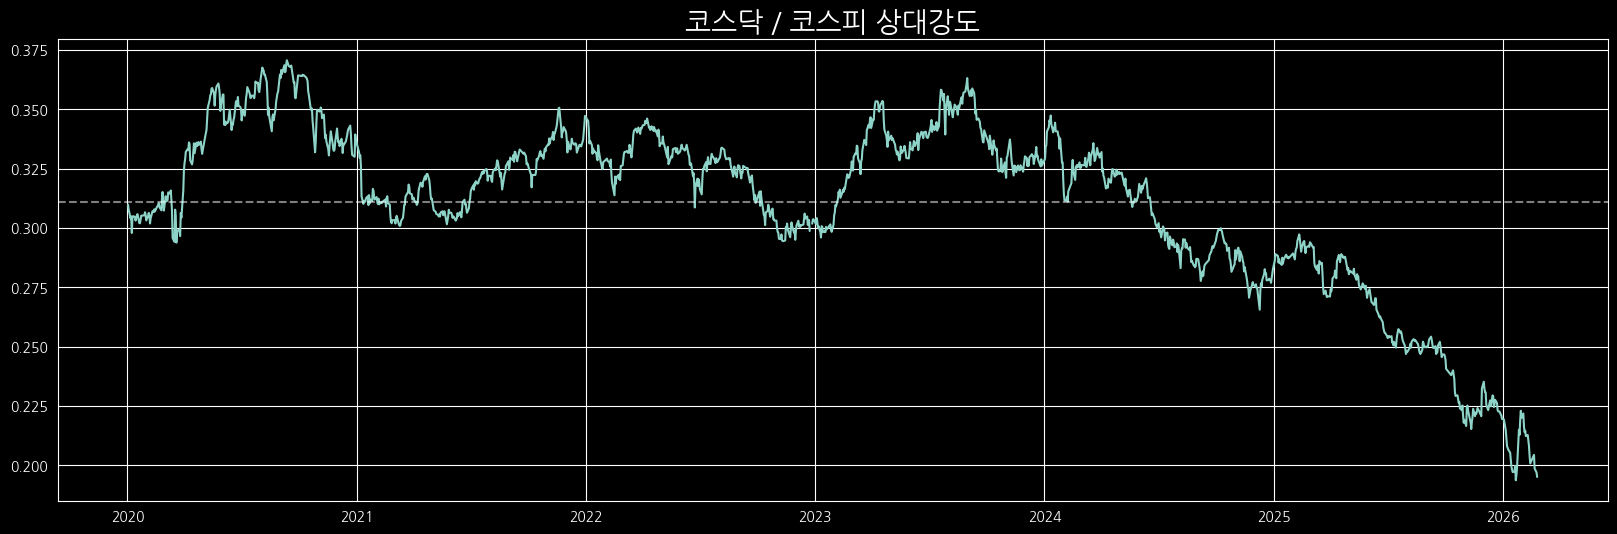

In [23]:
kospi = yf.download("^KS11", start="2020-01-01")    # KOSPI
kosdaq = yf.download("^KQ11", start="2020-01-01")  # KOSDAQ

df_rel = kospi.join(kosdaq)
df_rel.columns = [ f"{col[0]}_{col[1]}" for col in df_rel.columns]
df_rel['KOSDAQ_vs_KOSPI'] = df_rel['Close_^KQ11'] / df_rel['Close_^KS11']


plt.figure(figsize=(20,6))
plt.plot(df_rel.index, df_rel['KOSDAQ_vs_KOSPI'])
plt.title("코스닥 / 코스피 상대강도", fontsize=20)
plt.axhline(df_rel['KOSDAQ_vs_KOSPI'].mean(), linestyle='--', alpha=0.5)
plt.show()

In [30]:
df_rel.tail()

,Close_^KS11,High_^KS11,Low_^KS11,Open_^KS11,Volume_^KS11,Close_^KQ11,High_^KQ11,Low_^KQ11,Open_^KQ11,Volume_^KQ11,KOSDAQ_vs_KOSPI
Date,,,,,,,,,,,
2026-02-09,5298.040039,5322.350098,5265.080078,5299.100098,617700,1127.550049,1131.719971,1106.069946,1109.910034,1100,0.212824
2026-02-10,5301.689941,5363.620117,5286.669922,5350.209961,712300,1115.199951,1141.670044,1109.439941,1132.239990,1300,0.210348
2026-02-11,5354.490234,5374.229980,5257.529785,5293.750000,753800,1114.869995,1126.099976,1110.530029,1120.619995,1300,0.208212
2026-02-12,5522.270020,5522.270020,5399.520020,5425.390137,750600,1125.989990,1127.800049,1110.180054,1122.550049,1600,0.203900
2026-02-13,5507.009766,5583.740234,5480.919922,5513.709961,1290700,1106.079956,1117.910034,1099.619995,1113.530029,1500,0.200849
